<a href="https://colab.research.google.com/github/manyasethi777-sketch/Handwritten-digital-recognition-using-ML/blob/main/handwritten_digital_recogn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HANDWRITTEN DIGITAL RECOGNITION


KNN

In [1]:
# Basic imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# Load MNIST dataset
X, y = fetch_openml('mnist_784', version=1, return_X_y=True)

# Convert labels to integers
y = y.astype(int)

# Normalize data
X = X / 255.0

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)


Training samples: (56000, 784)
Testing samples: (14000, 784)


SVM

KNN (k=3) Accuracy: 0.9712857142857143


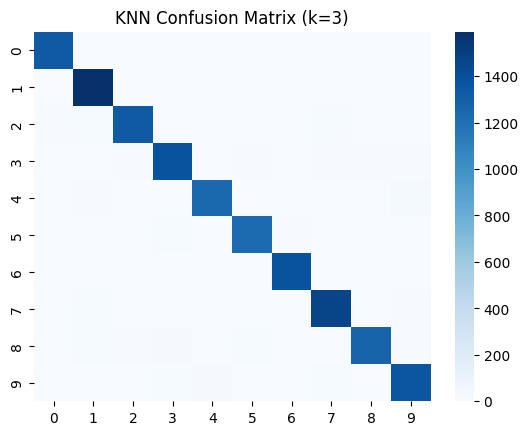

In [2]:
from sklearn.neighbors import KNeighborsClassifier

# KNN with k = 3
knn_3 = KNeighborsClassifier(n_neighbors=3)
knn_3.fit(X_train, y_train)
y_pred_knn3 = knn_3.predict(X_test)

acc_knn3 = accuracy_score(y_test, y_pred_knn3)
print("KNN (k=3) Accuracy:", acc_knn3)

cm_knn3 = confusion_matrix(y_test, y_pred_knn3)
sns.heatmap(cm_knn3, cmap="Blues", fmt="d")
plt.title("KNN Confusion Matrix (k=3)")
plt.show()


SVM
reducing the dataset size to avoid a long runtime

In [6]:
X_train_svm = X_train[:10000]
y_train_svm = y_train[:10000]

X_test_svm = X_test[:2000]
y_test_svm = y_test[:2000]

print("SVM train shape:", X_train_svm.shape)
print("SVM test shape:", X_test_svm.shape)


SVM train shape: (10000, 784)
SVM test shape: (2000, 784)


SVM


SVM Linear Accuracy: 0.9075


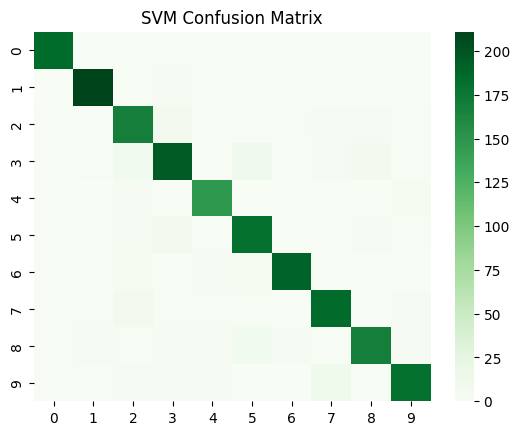

In [7]:
from sklearn.svm import SVC

svm_linear = SVC(kernel='linear', C=1)
svm_linear.fit(X_train_svm, y_train_svm)

y_pred_svm = svm_linear.predict(X_test_svm)

acc_svm = accuracy_score(y_test_svm, y_pred_svm)
print("SVM Linear Accuracy:", acc_svm)

cm_svm = confusion_matrix(y_test_svm, y_pred_svm)
sns.heatmap(cm_svm, cmap="Greens", fmt="d")
plt.title("SVM Confusion Matrix")
plt.show()


CNN

In [8]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
# Reshape for CNN
X_train_cnn = X_train.values.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.values.reshape(-1, 28, 28, 1)

# One-hot encode labels
y_train_cnn = to_categorical(y_train, 10)
y_test_cnn = to_categorical(y_test, 10)


cnn = Sequential([
    Conv2D(32, kernel_size=3, activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn.fit(X_train_cnn, y_train_cnn, epochs=5, batch_size=128, validation_split=0.1)

cnn_loss, cnn_acc = cnn.evaluate(X_test_cnn, y_test_cnn)
print("CNN Accuracy:", cnn_acc)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
394/394 ━━━━━━━━━━━━━━━━━━━━ 26s 63ms/step - accuracy: 0.8622 - loss: 0.5111 - val_accuracy: 0.9718 - val_loss: 0.0943
Epoch 2/5
394/394 ━━━━━━━━━━━━━━━━━━━━ 41s 63ms/step - accuracy: 0.9772 - loss: 0.0798 - val_accuracy: 0.9820 - val_loss: 0.0629
Epoch 3/5
394/394 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.9868 - loss: 0.0474 - val_accuracy: 0.9837 - val_loss: 0.0526
Epoch 4/5
394/394 ━━━━━━━━━━━━━━━━━━━━ 38s 55ms/step - accuracy: 0.9889 - loss: 0.0365 - val_accuracy: 0.9868 - val_loss: 0.0484
Epoch 5/5
394/394 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.9922 - loss: 0.0259 - val_accuracy: 0.9839 - val_loss: 0.0497
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9823 - loss: 0.0540
CNN Accuracy: 0.9829999804496765
